### Initial EDA  

Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Load Data Set

In [60]:
df = pd.read_csv('../Data/fraud_raw.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [62]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [63]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

### Univariate EDA

Univariate EDA — Numeric Features

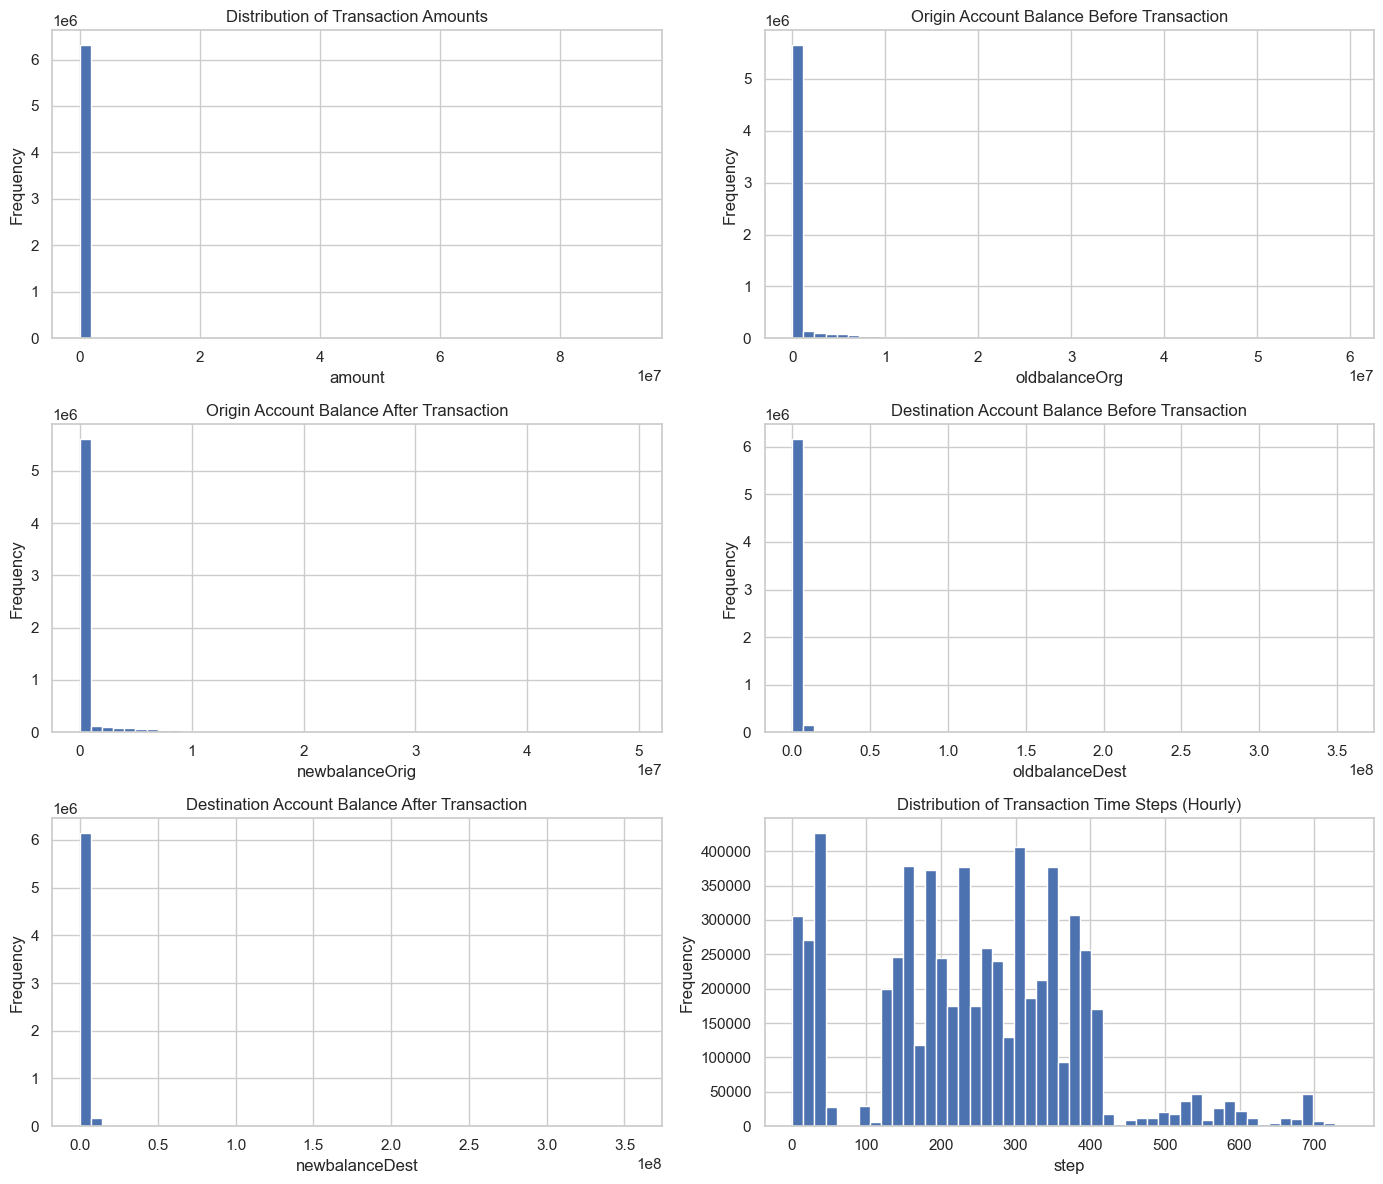

In [64]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(titles.items()):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(title)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



Univariate EDA — Categorical Features

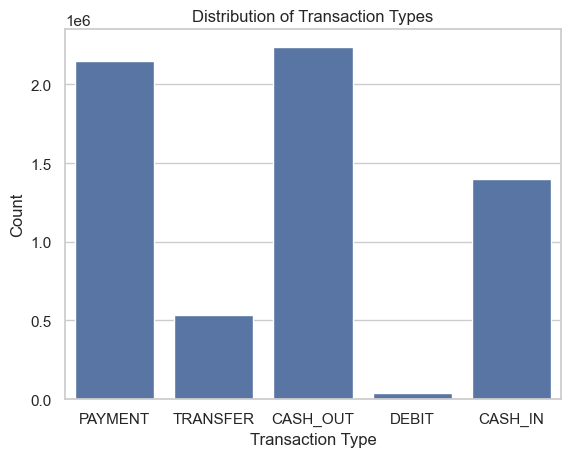

In [65]:
sns.countplot(x='type', data=df)
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()


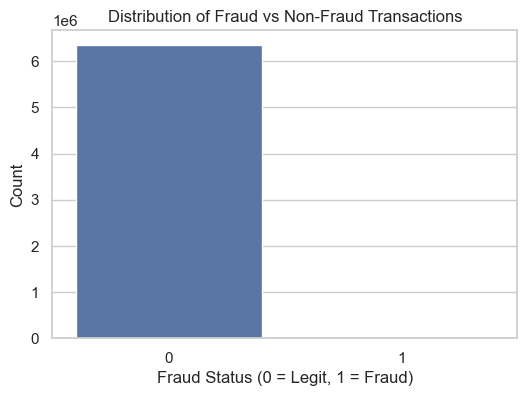

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.show()


The transaction features all show a similar pattern: most activity in this dataset involves very small amounts of money and accounts that hold very low balances, both before and after money moves. Only a small portion of transactions involve large transfers or accounts with substantial funds, which creates the strong skew toward zero seen in nearly every graph.

The timing feature shows a more spread‑out pattern, meaning transactions occur across many hours rather than clustering at one point in time. Some hours see more activity than others, hinting at possible behavioral rhythms.

The distribution of transaction types shows that everyday actions, like sending money out or making payments, dominate the dataset, while other types occur far less often.

Finally, the fraud indicator shows an extreme imbalance: almost all transactions are legitimate. Fraudulent activity makes up only a tiny fraction of the dataset. This imbalance is important because it means the dataset is heavily skewed toward normal behavior, and any modeling later will need to account for this.

### Bivariate EDA

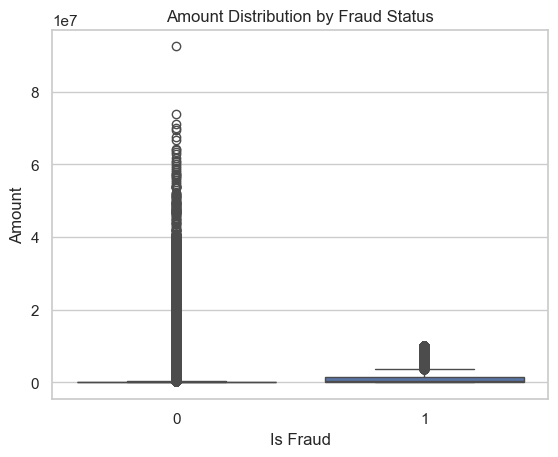

In [67]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Amount Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.show()


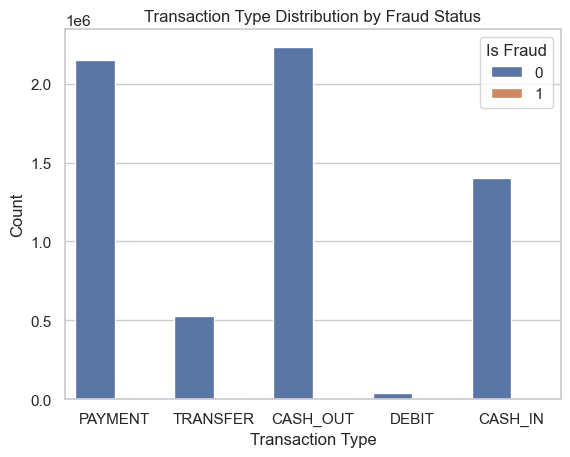

In [68]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Transaction Type Distribution by Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(title='Is Fraud')
plt.show()


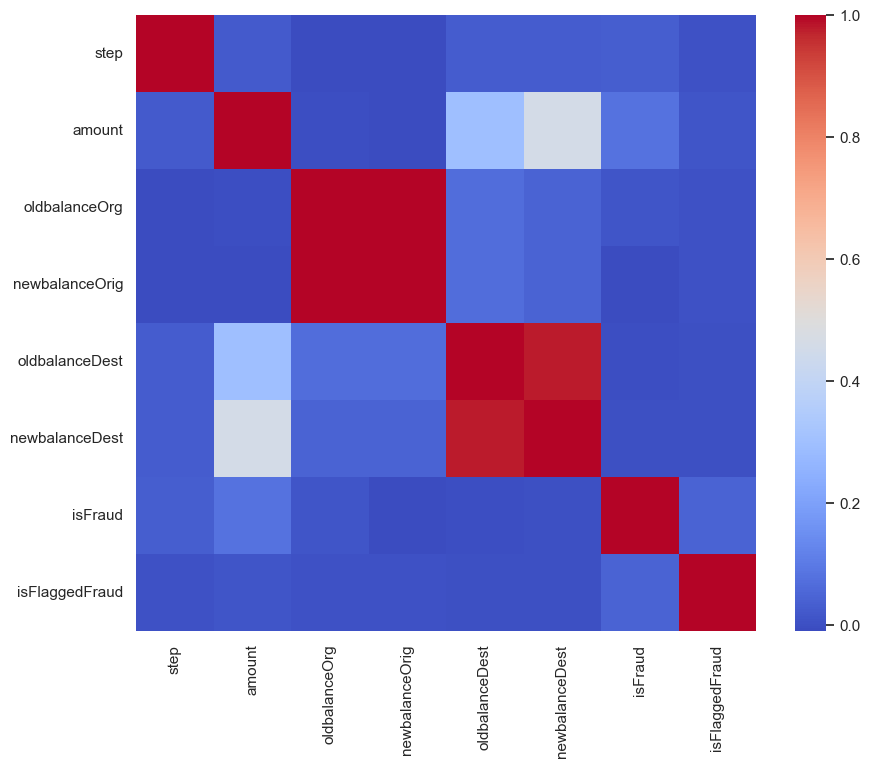

In [69]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()


The heatmap shows how different parts of a transaction relate to each other. What stands out most is that the balances before a transaction and the balances after a transaction are almost perfectly connected. In other words, the amount of money an account starts with and the amount it ends with tend to move together in predictable ways.

You also see that accounts receiving money behave the same way: the balance before receiving funds and the balance after receiving funds rise and fall together. These pairs of features are telling the same story, which means they may be redundant.

The transaction amount has a moderate relationship with account balances. Larger transactions tend to come from accounts that already hold more money, which is a normal pattern in financial behavior.

The fraud indicator, however, does not show strong linear relationships with any of the transaction features. This is expected in fraud detection. Fraud rarely shows up as a simple straight‑line relationship. Instead, fraud tends to emerge from unusual combinations of behaviors rather than one single variable.

Finally, the flagged‑transaction indicator shows almost no meaningful relationship with anything else. It doesn’t align with actual fraud cases and doesn’t help explain transaction behavior.

### Multivariate EDA

Origin Account Balance Change

c:\Users\Zaria\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


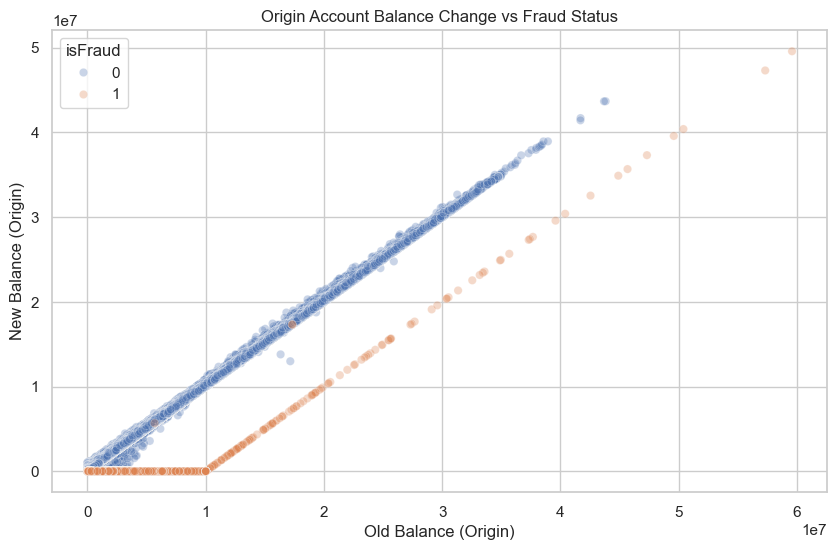

In [70]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='oldbalanceOrg',
    y='newbalanceOrig',
    hue='isFraud',
    data=df,
    alpha=0.3
)
plt.title('Origin Account Balance Change vs Fraud Status')
plt.xlabel('Old Balance (Origin)')
plt.ylabel('New Balance (Origin)')
plt.show()


Across these comparisons, a clear pattern emerges in how accounts behave during normal transactions versus fraudulent ones. When money moves out of an account, legitimate activity tends to follow a predictable path: whatever the account starts with, it usually ends with a similar, proportional amount. This creates a clean diagonal pattern where the “before” and “after” values rise and fall together.

Fraudulent activity breaks this pattern. In the first graph, the sending account often begins with money but ends with noticeably less, sometimes dropping straight to zero. This creates a cluster of points where the “after” value is much lower than expected. It’s a signature of accounts being drained.

Destination Account Balance Change

c:\Users\Zaria\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


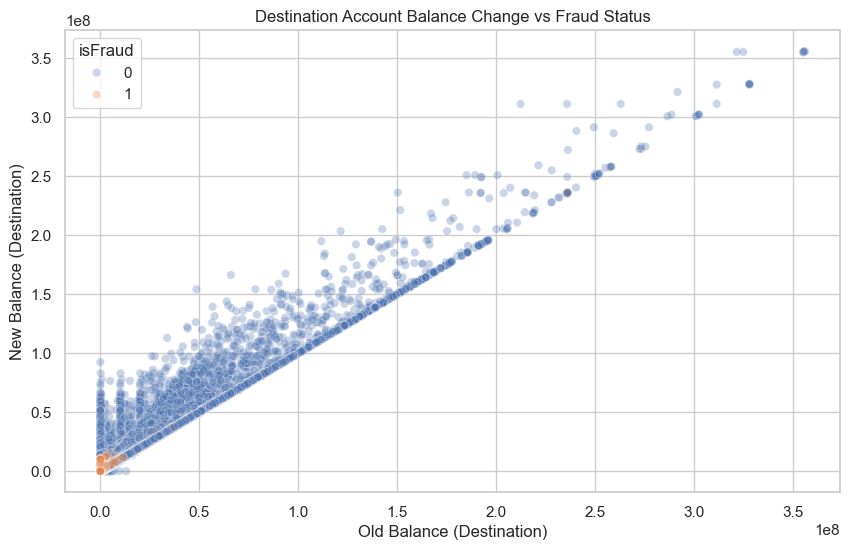

In [71]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='oldbalanceDest',
    y='newbalanceDest',
    hue='isFraud',
    data=df,
    alpha=0.3
)
plt.title('Destination Account Balance Change vs Fraud Status')
plt.xlabel('Old Balance (Destination)')
plt.ylabel('New Balance (Destination)')
plt.show()


The second graph shows the receiving side. Normal transactions again follow a smooth diagonal, where the balance after receiving money matches what came before. Fraudulent cases, however, tend to appear near the bottom of the plot — accounts that start with almost nothing and end with unusual jumps or irregular changes. These behaviors stand out from the typical flow of funds.

c:\Users\Zaria\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


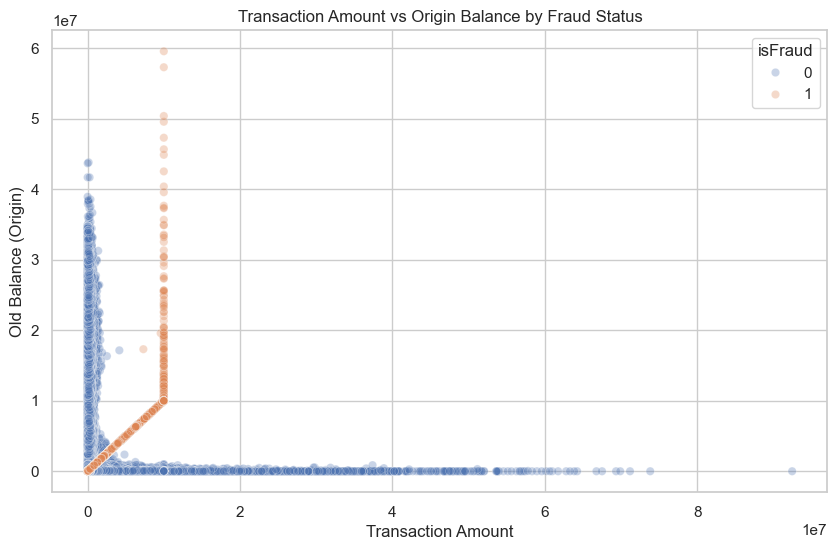

In [72]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='amount',
    y='oldbalanceOrg',
    hue='isFraud',
    data=df,
    alpha=0.3
)
plt.title('Transaction Amount vs Origin Balance by Fraud Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Old Balance (Origin)')
plt.show()


The final graph compares how much money is being moved to how much the sending account originally held. Legitimate transactions cluster tightly near small amounts and small balances, reflecting everyday low‑value activity. Fraudulent cases stretch into higher ranges, showing large transfers coming from accounts with substantial funds. These cases form distinct patterns that separate them from normal behavior.

#### Hypothesis

Together, these graphs show that fraudulent transactions break the normal flow of money. While legitimate activity shows smooth, proportional changes in account balances and mostly small transfers, fraudulent transactions create unusual balance drops, sudden jumps, or large transfers that don’t match typical behavior. Because these irregular patterns stand out from the predictable structure of normal transactions, they can be identified and used to detect fraud.